# Text Mining Project — Agentic LLM Solutions, full story v1→v4 (`tm_agents_tests_12`)

**Group 12** | Market-sentiment classification: Bearish (0) / Bullish (1) / Neutral (2)

Consolidated experiment notebook: every LLM version's prompts and code, all results resumed
from `cache_agents/` (a full Run All makes **zero** Azure calls once caches are complete).
v4's expensive experiment (Optuna study) lives in `tm_v4_optuna_12.ipynb`; this notebook
loads its logged predictions and folds them into the same results-history log.

## 0. Setup

In [ ]:
# !pip install -q langchain langchain-openai langchain-core langchain-community langchain-classic
# !pip install -q scikit-learn pandas matplotlib tqdm
# !pip install -q langchain-huggingface chromadb sentence-transformers   # for the v3 RAG section

## 1. Azure OpenAI connection *(Lab 6 conventions)*

In [1]:
import os, json, re, time, hashlib, glob
RANDOM_STATE = 42
DATA_DIR  = "data/"
CACHE_DIR = "cache_agents/"            # agent predictions + results history log live here
EMB_CACHE = "cache/"                   # tm_tests_12's cached embeddings (for the submitted baseline)
os.makedirs(CACHE_DIR, exist_ok=True)

KEY_PATH = next((p for p in ["../Lab6/Azure Open AI Key.txt", "../Lab 6/Azure Open AI Key.txt",
                             "Azure Open AI Key.txt"] if os.path.exists(p)),
                "../Lab6/Azure Open AI Key.txt")
AZURE_ENDPOINT = "https://novaimsplayground.openai.azure.com/"
AZURE_MODEL    = "ChatGPT"
API_VERSION    = "2024-02-15-preview"
print("Key file:", KEY_PATH, "| exists:", os.path.exists(KEY_PATH))

Key file: ../Lab6/Azure Open AI Key.txt | exists: True


In [2]:
from langchain_openai import AzureChatOpenAI
with open(KEY_PATH, encoding="utf-8") as f:
    key = f.read().strip()
os.environ["AZURE_OPENAI_KEY"] = key
os.environ["AZURE_OPENAI_ENDPOINT"] = AZURE_ENDPOINT
llm = AzureChatOpenAI(temperature=0, model=AZURE_MODEL, azure_endpoint=AZURE_ENDPOINT,
                      openai_api_type="azure", api_key=key, api_version=API_VERSION)
print("LLM ready:", llm.model_name)

LLM ready: ChatGPT


In [3]:
try:
    print(llm.invoke("Reply with the single word: ready").content)
except Exception as e:
    print("Azure call failed:", e)

ready


## 2. Data — reproduce the *exact* validation split (`random_state=42`)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

LABEL_NAMES = {0: "bearish", 1: "bullish", 2: "neutral"}
NAME_TO_ID  = {v: k for k, v in LABEL_NAMES.items()}
LBL = LABEL_NAMES                                   # alias used by the runner

def read_csv_safe(p):
    for enc in ["utf-8", "latin-1"]:
        try: return pd.read_csv(p, encoding=enc)
        except UnicodeDecodeError: continue
    raise ValueError(p)

train_df = read_csv_safe(DATA_DIR + "train.csv")
train_df.columns = [c.strip().lower() for c in train_df.columns]
X = train_df["text"].reset_index(drop=True); y = train_df["label"].reset_index(drop=True)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train_raw = X_train_raw.reset_index(drop=True); X_val_raw = X_val_raw.reset_index(drop=True)
y_train = y_train.reset_index(drop=True); y_val = y_val.reset_index(drop=True)
print("train:", len(X_train_raw), "| val:", len(X_val_raw))
print("val balance:", {LABEL_NAMES[k]: int(v) for k, v in y_val.value_counts().sort_index().items()})

c:\Users\artem\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


train: 7634 | val: 1909
val balance: {'bearish': 288, 'bullish': 385, 'neutral': 1236}


## 3. Prompts — base vs improved

System prompts carry only the *labeling guidance*; the *output format* (one word vs JSON map) is
added per call by the runner, so the same prompt works in both single-call and mini-batch modes.

In [5]:
# ---- BASE prompts (v1) — restored verbatim from tm_agents_12_v4_recovered ----
CLASSIFIER_SYSTEM = (
    "You are a financial-sentiment classifier for stock-market tweets. "
    "Classify the sentiment expressed toward the asset/market as exactly one of: "
    "bearish, bullish, neutral.\n"
    "- bearish = expects price to fall / negative outlook / bad news for the asset\n"
    "- bullish = expects price to rise / positive outlook / good news for the asset\n"
    "- neutral = factual, a question, mixed, or no clear directional view\n"
    'Return ONLY compact JSON: {"label": "bearish|bullish|neutral", "reason": "<=8 words"}'
)
VALIDATOR_SYSTEM = (
    "You are a senior financial-sentiment reviewer. A junior classifier has labeled a tweet. "
    "Your job is to verify whether that label is truly correct. Re-read the tweet carefully and "
    "consider: sarcasm, negation, hedging, and that purely factual statements or questions are "
    "NEUTRAL (not directional). Allowed labels: bearish, bullish, neutral.\n"
    "Return ONLY compact JSON: "
    '{"verdict": "agree|disagree", "final_label": "bearish|bullish|neutral", "why": "<=12 words"}'
)

# ---- IMPROVED prompts (v1b / v2 / v3) — restored verbatim from tm_agents_12_v4_recovered ----
FEWSHOT = [
    ("$VIAC: Barrington Research cuts to Mkt Perform", "bearish"),
    ("$JE - Just Energy reports lower than expected Q3 EBITDA; revises guidance", "bearish"),
    ("Wayfair shares surge 37% as coronavirus drives sales of home decor", "bullish"),
    ("Oil trades at 3-month high", "bullish"),
    ("$PEP - PepsiCo declares $0.955 dividend", "neutral"),
    ("$VIPS - Vipshop announces business cooperation with SF Holding", "neutral"),
]
_fewshot_txt = "\n".join(f'  Tweet: "{t}"  ->  {lab}' for t, lab in FEWSHOT)

NEUTRAL_RULE = (
    "A factual statement, news headline, analyst/price-target or rating note, dividend/earnings "
    "figure, corporate announcement, or a question with no clear directional opinion is NEUTRAL. "
    "Only choose bearish or bullish when the author expresses a directional view, or the news is "
    "unambiguously good or bad for the asset's price. When genuinely unsure between neutral and a "
    "direction, choose NEUTRAL."
)

CLASSIFIER_SYSTEM_V2 = (
    "You are a financial-sentiment classifier for stock-market tweets. Label each tweet's sentiment "
    "toward the asset/market as exactly one of: bearish, bullish, neutral.\n"
    "- bearish = expects price to fall / negative outlook / clearly bad news for the asset\n"
    "- bullish = expects price to rise / positive outlook / clearly good news for the asset\n"
    "- neutral = factual / mixed / no directional view.\n"
    f"IMPORTANT RULE: {NEUTRAL_RULE}\n"
    "Examples:\n" + _fewshot_txt
)
VALIDATOR_SYSTEM_V2 = (
    "You are a senior reviewer correcting a junior classifier whose known weakness is OVER-CALLING "
    "sentiment: it labels factual/neutral tweets as bearish or bullish. For each tweet and its "
    "proposed label, decide the correct final label (bearish, bullish, neutral).\n"
    f"RULE: {NEUTRAL_RULE}\n"
    "If the proposed label is bearish or bullish but the tweet is merely factual with no directional "
    "opinion, correct it to neutral. If the proposed label already looks right, keep it. Do not flip "
    "neutral into a direction unless the tweet clearly expresses one."
)
print("prompts ready (restored from v4_recovered) | few-shot examples:", len(FEWSHOT))


prompts ready (restored from v4_recovered) | few-shot examples: 6


## 4. Core helpers + the reusable two-agent runner

`run_two_agent(...)` is the single engine behind v1, v1b and v2 — it only varies by the prompts you
pass and `mode` (`"single"` = one call per tweet, the v1 method; `"batch"` = mini-batched, the v2
method). It resumes from its cache file and logs metrics to the history log.

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage

def safe_json(text):
    if text is None: return {}
    text = re.sub(r"^```(?:json)?|```$", "", text.strip(), flags=re.MULTILINE).strip()
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not m: return {}
    try: return json.loads(m.group(0))
    except Exception: return {}

def norm_label(s):
    if s is None: return None
    s = str(s).strip().lower()
    for name, idx in NAME_TO_ID.items():
        if name in s: return idx
    return int(s) if s in {"0","1","2"} else None

def _invoke(system, user, retries=4):
    for a in range(retries):
        try: return llm.invoke([SystemMessage(content=system), HumanMessage(content=user)]).content
        except Exception:
            if a == retries - 1: raise
            time.sleep(2 ** a)

def _parse_map(raw, ids):
    d = safe_json(raw)
    return {i: (norm_label(d.get(str(i))) if isinstance(d, dict) else None) for i in ids}

def _chunks(seq, n):
    for i in range(0, len(seq), n): yield seq[i:i+n]

def _classify_one(system, tweet):
    """Classifier returns (label_id or None, reason) — JSON label+reason as in the original pipeline."""
    raw = _invoke(system, f'Classify this tweet:\n"""{tweet}"""\n'
                          'Return ONLY compact JSON: '
                          '{"label": "bearish|bullish|neutral", "reason": "<=8 words"}')
    d = safe_json(raw)
    return norm_label(d.get("label")), str(d.get("reason", ""))

def _validate_one(system, tweet, proposed_name, reason=""):
    """Validator sees the proposed label AND the classifier's reason; confirms or corrects."""
    raw = _invoke(system, f'Tweet:\n"""{tweet}"""\n'
                          f'Junior classifier proposed: {proposed_name}  (reason: {reason})\n'
                          f'Is this indeed a {proposed_name} tweet? Confirm or correct it.\n'
                          'Return ONLY compact JSON: {"verdict": "agree|disagree", '
                          '"final_label": "bearish|bullish|neutral", "why": "<=12 words"}')
    v = safe_json(raw)
    fin = norm_label(v.get("final_label"))
    return fin if fin is not None else norm_label(proposed_name)

def _classify_batch(system, ids):
    payload = {str(i): X_val_raw[i] for i in ids}
    user = ('Classify EVERY tweet. Return ONLY a JSON object mapping each id to "bearish","bullish" '
            'or "neutral".\n' + json.dumps(payload, ensure_ascii=False))
    got = _parse_map(_invoke(system, user), ids)
    for i in ids:
        if got[i] is None: got[i] = _classify_one(system, X_val_raw[i])[0]
        if got[i] is None: got[i] = 2
    return got

def _validate_batch(system, ids, proposed):
    payload = {str(i): {"tweet": X_val_raw[i], "proposed": LBL[proposed[i]]} for i in ids}
    user = ('For each item return the correct final label. Return ONLY a JSON object mapping each id '
            'to "bearish","bullish" or "neutral".\n' + json.dumps(payload, ensure_ascii=False))
    got = _parse_map(_invoke(system, user), ids)
    for i in ids:
        if got[i] is None: got[i] = _validate_one(system, X_val_raw[i], LBL[proposed[i]])
        if got[i] is None: got[i] = proposed[i]
    return got

In [7]:
from tqdm import tqdm

def run_two_agent(cache_file, classifier_system, validator_system, log_name,
                  mode="single", batch_size=15, use_validator=True, limit=None):
    """Reusable classify->validate runner over the validation set.
       Resumes from cache_file; logs metrics to the history log under log_name; returns (yt, yp)."""
    raw = json.load(open(cache_file)) if os.path.exists(cache_file) else {}
    res = {str(int(k.split("_")[0])): v for k, v in raw.items()}   # tolerate old '{idx}_{hash}' keys
    n_eval = len(X_val_raw) if limit is None else min(limit, len(X_val_raw))
    todo = [i for i in range(n_eval) if str(i) not in res]
    print(f"[{log_name}] cached {len(res)} | to run {len(todo)} (mode={mode}, validator={use_validator})")

    if mode == "single":
        for idx in tqdm(todo, desc=log_name):
            t = X_val_raw[idx]
            prop, reason = _classify_one(classifier_system, t)
            if prop is None: prop = 2
            fin  = _validate_one(validator_system, t, LBL[prop], reason) if use_validator else prop
            if fin is None: fin = prop
            res[str(idx)] = {"proposed": prop, "final": fin, "truth": int(y_val[idx]), "reason": reason}
            if len(res) % 25 == 0: json.dump(res, open(cache_file, "w"))
    else:
        for batch in tqdm(list(_chunks(todo, batch_size)), desc=log_name):
            prop = _classify_batch(classifier_system, batch)
            fin  = _validate_batch(validator_system, batch, prop) if use_validator else prop
            for i in batch:
                res[str(i)] = {"proposed": prop[i], "final": fin[i], "truth": int(y_val[i])}
            json.dump(res, open(cache_file, "w"))
    json.dump(res, open(cache_file, "w"))

    o = sorted(((k, v) for k, v in res.items() if int(k) < n_eval), key=lambda kv: int(kv[0]))
    yt = np.array([v["truth"] for _, v in o]); yp = np.array([v["final"] for _, v in o])
    pa = np.array([v["proposed"] for _, v in o])
    log_result(log_name, yt, yp, meta={"mode": mode, "use_validator": use_validator, "cache": cache_file,
                                       "n_eval": n_eval,
                                       "validator_flips_to_neutral": int(((pa != 2) & (yp == 2)).sum()),
                                       "validator_flips_from_neutral": int(((pa == 2) & (yp != 2)).sum())})
    return yt, yp

## 5. Results history log

Every model calls `log_result(name, y_true, y_pred)`, which computes and stores its metrics in
`cache_agents/results_log.json`. `leaderboard()` and `compare_per_class()` read only from this file,
so all comparisons are reproducible from data — never hard-coded.

In [8]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

RESULTS_LOG = os.path.join(CACHE_DIR, "results_log.json")

def log_result(name, y_true, y_pred, meta=None):
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    pc = {}
    for c, nm in LABEL_NAMES.items():
        tp=int(((yp==c)&(yt==c)).sum()); fp=int(((yp==c)&(yt!=c)).sum()); fn=int(((yp!=c)&(yt==c)).sum())
        pr=tp/(tp+fp) if tp+fp else 0.0; rc=tp/(tp+fn) if tp+fn else 0.0
        pc[nm] = {"precision":pr, "recall":rc, "f1": 2*pr*rc/(pr+rc) if pr+rc else 0.0,
                  "support": int((yt==c).sum())}
    entry = {"name": name, "macro_f1": float(f1_score(yt, yp, average="macro")),
             "weighted_f1": float(f1_score(yt, yp, average="weighted")),
             "accuracy": float(accuracy_score(yt, yp)), "per_class": pc,
             "neutral_leak": int(((yp!=2)&(yt==2)).sum()), "n": int(len(yt)), "meta": meta or {}}
    log = json.load(open(RESULTS_LOG)) if os.path.exists(RESULTS_LOG) else {}
    log[name] = entry
    json.dump(log, open(RESULTS_LOG, "w"), indent=2)
    print(f"[log] {name:52s} macro-F1 {entry['macro_f1']:.3f} | acc {entry['accuracy']:.3f}")
    return entry

def load_log():
    return json.load(open(RESULTS_LOG)) if os.path.exists(RESULTS_LOG) else {}

def leaderboard():
    log = load_log()
    if not log: print("(log empty — run experiments first)"); return
    print(f"{'Model':54s} {'Macro-F1':>9s} {'Accuracy':>9s} {'Neutral-leak':>14s}")
    print("-"*90)
    for e in sorted(log.values(), key=lambda e: -e["macro_f1"]):
        sup = e["per_class"]["neutral"]["support"]
        print(f"{e['name']:54s} {e['macro_f1']:9.3f} {e['accuracy']:9.3f} "
              f"{e['neutral_leak']:>6d}/{sup} ({100*e['neutral_leak']/sup:4.1f}%)")

def compare_per_class(name_a, name_b):
    log = load_log()
    if name_a not in log or name_b not in log:
        print("missing from log:", [n for n in (name_a, name_b) if n not in log]); return
    A, B = log[name_a]["per_class"], log[name_b]["per_class"]
    print(f"{'':9s}  {name_a[:26]:>26s}     {name_b[:26]:>26s}")
    print(f"{'class':9s} {'P':>6s}{'R':>6s}{'F1':>7s}      {'P':>6s}{'R':>6s}{'F1':>7s}   {'dF1':>7s}")
    for nm in ["bearish", "bullish", "neutral"]:
        a, b = A[nm], B[nm]
        print(f"{nm:9s} {a['precision']:6.3f}{a['recall']:6.3f}{a['f1']:7.3f}      "
              f"{b['precision']:6.3f}{b['recall']:6.3f}{b['f1']:7.3f}   {b['f1']-a['f1']:+7.3f}")
    da = log[name_b]["macro_f1"] - log[name_a]["macro_f1"]
    print(f"\nmacro-F1  {log[name_a]['macro_f1']:.3f} -> {log[name_b]['macro_f1']:.3f}  ({da:+.3f})")
    print(f"accuracy  {log[name_a]['accuracy']:.3f} -> {log[name_b]['accuracy']:.3f}")

# canonical names (used as log keys everywhere)
N_SUB = "Submitted: Concat FinBERT+twitter-roberta -> MLP"
N_V1  = "LLM v1 (base prompts, single-call)"
N_V1B = "LLM v1b (improved prompts, single-call)"
N_V2  = "LLM v2 (improved prompts, mini-batch)"
N_V3  = "LLM v3 (dynamic few-shot RAG, k=8)"
print("history log ->", RESULTS_LOG)

history log -> cache_agents/results_log.json


## 6. Submitted baseline — recomputed from cached embeddings (not hard-coded)

Rebuilds the submitted model (concat FinBERT[CLS] + twitter-roberta[CLS] → MLP(256,128),
`random_state=42`) from the embeddings `tm_tests_12` cached, predicts the same validation split, and
logs its real metrics. Trains in seconds; no Azure, no re-embedding.

In [9]:
from sklearn.neural_network import MLPClassifier

def _emb(name):
    p = os.path.join(EMB_CACHE, name)
    return np.load(p, allow_pickle=True) if os.path.exists(p) else None

fb_tr, fb_va = _emb("emb_finbert_cls_train.npy"), _emb("emb_finbert_cls_val.npy")
tr_tr, tr_va = _emb("emb_twitter_roberta_cls_train.npy"), _emb("emb_twitter_roberta_cls_val.npy")

if all(a is not None for a in (fb_tr, fb_va, tr_tr, tr_va)):
    assert fb_va.shape[0] == len(y_val) and fb_tr.shape[0] == len(y_train), "embedding/split mismatch"
    Xtr_c = np.hstack([fb_tr, tr_tr]); Xva_c = np.hstack([fb_va, tr_va])
    sub_clf = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400,
                            early_stopping=True, random_state=RANDOM_STATE).fit(Xtr_c, y_train)
    log_result(N_SUB, np.asarray(y_val), sub_clf.predict(Xva_c), meta={"source": "cached embeddings"})
else:
    print("WARNING: cached embeddings missing in ./cache — run tm_tests_12 caching, or skip baseline.")

[log] Submitted: Concat FinBERT+twitter-roberta -> MLP     macro-F1 0.808 | acc 0.859


## 7. Experiment v1 — base prompts, single-call

Resumes from the existing `val_preds_rounds1.json` cache (no Azure calls if already complete).

In [10]:
# Set to an int (e.g. 300) to evaluate on only the first N validation records; None = full set
EVAL_LIMIT = None

In [11]:
yt_v1, yp_v1 = run_two_agent(os.path.join(CACHE_DIR, "val_preds_rounds1.json"),
                             CLASSIFIER_SYSTEM, VALIDATOR_SYSTEM, N_V1, mode="single", limit=EVAL_LIMIT)

[LLM v1 (base prompts, single-call)] cached 1909 | to run 0 (mode=single, validator=True)


LLM v1 (base prompts, single-call): 0it [00:00, ?it/s]

[log] LLM v1 (base prompts, single-call)                   macro-F1 0.775 | acc 0.798


## 8. Experiment v1b — improved prompts, single-call  *(replaces the removed self-consistency experiment)*

The same single-call v1 method, but with the improved prompts (tightened neutral rule + few-shot).
This isolates the effect of the prompts from the mini-batching used in v2. **This is the one new
experiment that actually calls Azure (~2 calls/tweet) — it has no prior cache.**

In [12]:
yt_v1b, yp_v1b = run_two_agent(os.path.join(CACHE_DIR, "val_preds_v1b_single.json"),
                               CLASSIFIER_SYSTEM_V2, VALIDATOR_SYSTEM_V2, N_V1B, mode="single", limit=EVAL_LIMIT)

[LLM v1b (improved prompts, single-call)] cached 1909 | to run 0 (mode=single, validator=True)


LLM v1b (improved prompts, single-call): 0it [00:00, ?it/s]

[log] LLM v1b (improved prompts, single-call)              macro-F1 0.777 | acc 0.827


## 9. Experiment v2 — improved prompts, mini-batch

Resumes from the existing `val_preds_v2_bs15.json` cache.

In [13]:
yt_v2, yp_v2 = run_two_agent(os.path.join(CACHE_DIR, "val_preds_v2_bs15.json"),
                             CLASSIFIER_SYSTEM_V2, VALIDATOR_SYSTEM_V2, N_V2,
                             mode="batch", batch_size=15, limit=EVAL_LIMIT)

[LLM v2 (improved prompts, mini-batch)] cached 1909 | to run 0 (mode=batch, validator=True)


LLM v2 (improved prompts, mini-batch): 0it [00:00, ?it/s]


[log] LLM v2 (improved prompts, mini-batch)                macro-F1 0.789 | acc 0.832


## 10. Experiment v3 — dynamic few-shot (RAG)

For each tweet, retrieve its k nearest **training** tweets (with gold labels) from a Chroma store
(`thenlper/gte-small`, Lab 5b conventions) and use them as in-context examples. The store is built
once and persisted.

In [14]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

embedding_model = HuggingFaceEmbeddings(model_name="thenlper/gte-small",
    model_kwargs={"device": "cpu"}, encode_kwargs={"normalize_embeddings": True})
STORE_DIR = "chroma_trainstore"
if os.path.isdir(STORE_DIR) and os.listdir(STORE_DIR):
    vstore = Chroma(persist_directory=STORE_DIR, embedding_function=embedding_model)
    print("Loaded Chroma store.")
else:
    vstore = Chroma.from_texts([str(t) for t in X_train_raw.tolist()], embedding=embedding_model,
        metadatas=[{"label": int(l)} for l in y_train.tolist()], persist_directory=STORE_DIR)
    print("Built Chroma store with", len(X_train_raw), "training tweets.")

C:\Users\artem\AppData\Local\Temp\ipykernel_8612\2802523254.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

C:\Users\artem\AppData\Local\Temp\ipykernel_8612\2802523254.py:8: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vstore = Chroma(persist_directory=STORE_DIR, embedding_function=embedding_model)


Loaded Chroma store.


In [15]:
K_SHOT = 8
def retrieve_examples(tweet, k=K_SHOT):
    docs = vstore.similarity_search(tweet, k=k + 2); out = []
    for d in docs:
        if d.page_content.strip() == tweet.strip(): continue
        out.append((d.page_content, LABEL_NAMES[int(d.metadata["label"])]))
        if len(out) >= k: break
    return out

def classify_rag(tweet):
    shots = "\n".join(f'Tweet: "{t}"  ->  {lab}' for t, lab in retrieve_examples(tweet))
    user = ("Below are the most similar tweets from our labeled training data, with their correct "
            "labels. Use the SAME labeling standard they imply (especially for what counts as "
            "neutral vs directional):\n"
            f"{shots}\n\nNow classify THIS tweet:\n\"\"\"{tweet}\"\"\"\n"
            "Reply with ONLY one word: bearish, bullish or neutral.")
    return norm_label((_invoke(CLASSIFIER_SYSTEM_V2, user) or "").strip())

In [16]:
CACHE_V3 = os.path.join(CACHE_DIR, "val_preds_v3_rag_k8.json")
v3 = json.load(open(CACHE_V3)) if os.path.exists(CACHE_V3) else {}
n_eval = len(X_val_raw) if EVAL_LIMIT is None else min(EVAL_LIMIT, len(X_val_raw))
todo = [i for i in range(n_eval) if str(i) not in v3]
print(f"v3 RAG: cached {len(v3)} | to run {len(todo)} (k={K_SHOT})")
for idx in tqdm(todo, desc=N_V3):
    t = X_val_raw[idx]
    try:
        lab = classify_rag(t)
        if lab is None: lab = 2
    except Exception: lab = 2
    v3[str(idx)] = {"proposed": lab, "final": lab, "truth": int(y_val[idx])}
    if len(v3) % 25 == 0: json.dump(v3, open(CACHE_V3, "w"))
json.dump(v3, open(CACHE_V3, "w"))
o = sorted(((k, d) for k, d in v3.items() if int(k) < n_eval), key=lambda kv: int(kv[0]))
yt_v3 = np.array([d["truth"] for _, d in o]); yp_v3 = np.array([d["final"] for _, d in o])
log_result(N_V3, yt_v3, yp_v3, meta={"k": K_SHOT, "retrieval": "gte-small", "n_eval": n_eval})

v3 RAG: cached 1909 | to run 0 (k=8)


LLM v3 (dynamic few-shot RAG, k=8): 0it [00:00, ?it/s]

[log] LLM v3 (dynamic few-shot RAG, k=8)                   macro-F1 0.856 | acc 0.878


{'name': 'LLM v3 (dynamic few-shot RAG, k=8)',
 'macro_f1': 0.8556130046612508,
 'weighted_f1': 0.879689424027228,
 'accuracy': 0.8779465688842326,
 'per_class': {'bearish': {'precision': 0.7620481927710844,
   'recall': 0.8784722222222222,
   'f1': 0.8161290322580645,
   'support': 288},
  'bullish': {'precision': 0.8004640371229699,
   'recall': 0.8961038961038961,
   'f1': 0.8455882352941176,
   'support': 385},
  'neutral': {'precision': 0.9406631762652705,
   'recall': 0.872168284789644,
   'f1': 0.9051217464315702,
   'support': 1236}},
 'neutral_leak': 158,
 'n': 1909,
 'meta': {'k': 8, 'retrieval': 'gte-small', 'n_eval': 1909}}

In [17]:
print(retrieve_examples(X_val_raw[0]))

[('US Fertility Rate Hit Record Low In 2018 https://t.co/tZ83z6vVCZ', 'bearish'), ("Dear Moneyist,\nI don't want to be a money grab. My friend with lung disease wants to marry me so I receive his gene… https://t.co/2gNT8h06yG", 'neutral'), ('Three keys to avoiding new debt with a new baby #investinyou (In partnership with @acorns.) https://t.co/kyCywg5ex1', 'neutral'), ('A psychologist shares the 5 phrases parents should never say to their kids. (via @CNBCMakeIt) https://t.co/kGa8NQQHgj', 'neutral'), ('Yestar Healthcare : Next Day Disclosure Returns #YestarHealthcare #Stock #MarketScreener https://t.co/k6srQHazpf https://t.co/oW9KRoFuxU', 'neutral'), ('Highlight: “It’s very unclear as to who the target demographic is going to be,” @Melodyhahm says about the Tesla cy… https://t.co/oyerFjqoQ3', 'neutral'), ('Highlight: “It will be the first insulin pill in the history of insulin," Oramed CEO @NadavKidro says about their n… https://t.co/sJvKOoZFwl', 'neutral'), ("Americans aren't having a

## 11. Leaderboard — read entirely from the history log

In [18]:
leaderboard()

Model                                                   Macro-F1  Accuracy   Neutral-leak
------------------------------------------------------------------------------------------
LLM v3 (dynamic few-shot RAG, k=8)                         0.856     0.878    158/1236 (12.8%)
Submitted: Concat FinBERT+twitter-roberta -> MLP           0.808     0.859     93/1236 ( 7.5%)
LLM v2 (improved prompts, mini-batch)                      0.789     0.832    129/1236 (10.4%)
LLM v1b (improved prompts, single-call)                    0.777     0.827    112/1236 ( 9.1%)
LLM v1 (base prompts, single-call)                         0.775     0.798    304/1236 (24.6%)


## 12. Per-class comparison: submitted vs v3 (from the log)

Change `N_V3` to any logged model to compare a different pair.

In [19]:
compare_per_class(N_SUB, N_V3)

# full sklearn report for the winning model, straight from its cache
o = sorted(json.load(open(CACHE_V3)).items(), key=lambda kv: int(kv[0]))
yt = np.array([d['truth'] for _, d in o]); yp = np.array([d['final'] for _, d in o])
print()
print(classification_report(yt, yp, target_names=['bearish','bullish','neutral'], digits=3))
print('Confusion (rows=true, cols=pred):'); print(confusion_matrix(yt, yp, labels=[0,1,2]))

           Submitted: Concat FinBERT+     LLM v3 (dynamic few-shot R
class          P     R     F1           P     R     F1       dF1
bearish    0.807 0.667  0.730       0.762 0.878  0.816    +0.086
bullish    0.779 0.790  0.785       0.800 0.896  0.846    +0.061
neutral    0.892 0.925  0.908       0.941 0.872  0.905    -0.003

macro-F1  0.808 -> 0.856  (+0.048)
accuracy  0.859 -> 0.878

              precision    recall  f1-score   support

     bearish      0.762     0.878     0.816       288
     bullish      0.800     0.896     0.846       385
     neutral      0.941     0.872     0.905      1236

    accuracy                          0.878      1909
   macro avg      0.834     0.882     0.856      1909
weighted avg      0.885     0.878     0.880      1909

Confusion (rows=true, cols=pred):
[[ 253    2   33]
 [   5  345   35]
 [  74   84 1078]]


## 13. What to write in the report

- **Method.** Two-agent (classifier → validator) LLM pipeline on Azure OpenAI, all variants produced
  by one reusable runner that differs only by prompts and single-call vs mini-batch. A retrieval-
  augmented variant (v3) supplies k nearest labeled training tweets as in-context examples.
- **Fair comparison.** Every model is scored on the identical 1,909-tweet stratified validation split
  (`random_state=42`); the supervised baseline is recomputed from cached embeddings, and all numbers
  come from the shared results log — nothing hard-coded.
- **Result.** v3 (RAG) **beats the submitted supervised model** (fill in from §11; ~0.854 vs 0.808
  macro-F1). The error analysis shows the whole gap was the neutral-vs-directional boundary; dynamic
  few-shot taught the dataset's labeling convention, recovering minority-class (bear/bull) recall.
- **Ablation.** v1 → v1b isolates the prompt improvements (single-call, no batching); v1b → v2 shows
  the small effect of mini-batching; v2 → v3 shows the large effect of retrieval.
- **Note.** The earlier zero-shot decoder baseline (llama3.2:3b, macro-F1 0.446) was evaluated on a
  300-tweet subset in `tm_tests_12`, so it is reported separately rather than in this leaderboard.


---
# 14. v4 — batched RAG (similarity-grouped mini-batches), Optuna-tuned

v3 sends one Azure call per tweet. v4 groups *similar* validation tweets into homogeneous
mini-batches (KMeans on the same gte-small embeddings), gives each batch ONE shared, deduplicated
block of retrieved training examples, and classifies the whole batch in a single call. A dedicated
prompt tells the model that uniform labels within a batch are expected (no artificial balancing).
Hyper-parameters were tuned with **Optuna** (30 TPE trials on a stratified 400-tweet slice;
remaining 1,509 tweets = untouched confirmation holdout). Full experiment: `tm_v4_optuna_12.ipynb`.

**Best config:** `k=8, batch_size=10, max_shared_examples=24, retrieval_mode=nearest,
example_order=shuffled` — note Optuna independently re-discovered v3's k=8.

The v4 prompts are separate constants; v1–v3 prompts above are untouched.

In [20]:
# v4 system prompt (verbatim from tm_v4_optuna_12.ipynb) — shown for the record
NEUTRAL_RULE_V4 = (
    "A factual statement, news headline, analyst/price-target or rating note, dividend/earnings "
    "figure, corporate announcement, or a question with no clear directional opinion is NEUTRAL. "
    "Only choose bearish or bullish when the author expresses a directional view, or the news is "
    "unambiguously good or bad for the asset's price. When genuinely unsure between neutral and a "
    "direction, choose NEUTRAL."
)
CLASSIFIER_SYSTEM_V4 = (
    "You are a financial-sentiment classifier for stock-market tweets. Label each tweet's sentiment "
    "toward the asset/market as exactly one of: bearish, bullish, neutral.\n"
    "- bearish = expects price to fall / negative outlook / clearly bad news for the asset\n"
    "- bullish = expects price to rise / positive outlook / clearly good news for the asset\n"
    "- neutral = factual / mixed / no directional view.\n"
    f"IMPORTANT RULE: {NEUTRAL_RULE_V4}\n"
    "You will receive a SHARED EXAMPLE BLOCK of similar training tweets with their correct labels, "
    "followed by a JSON batch of tweets to classify. Use the SAME labeling standard the examples "
    "imply, especially for what counts as neutral vs directional.\n"
    "IMPORTANT: the batch was deliberately built from MUTUALLY SIMILAR tweets, so it is expected "
    "and perfectly normal that MOST OR ALL tweets in a batch share the same label. Do NOT try to "
    "balance or diversify labels across the batch. Judge each tweet on its own."
)
print("v4 prompt constants defined (display only — runs happen in tm_v4_optuna_12.ipynb).")

v4 prompt constants defined (display only — runs happen in tm_v4_optuna_12.ipynb).


## 14.1 Load v4 predictions from the experiment log and add them to the history log

In [21]:
V4_RUNS = os.path.join(CACHE_DIR, "v4_runs.jsonl")
v4_runs = [json.loads(l) for l in open(V4_RUNS) if l.strip()]
rec_full = next(r for r in v4_runs if r["tag"] == "v4_best_full1909")
rec_hold = next(r for r in v4_runs if r["tag"] == "v4_best_holdout")
seed_recs = [r for r in v4_runs if r["tag"].startswith("v4_best_full1909_seed")]

N_V4  = "LLM v4 (batched RAG, Optuna-tuned)"
N_V4H = "LLM v4 (batched RAG, holdout n=1509)"

p4 = {int(k): v for k, v in rec_full["preds"].items()}
yt4 = np.array([int(y_val[i]) for i in sorted(p4)]); yp4 = np.array([p4[i] for i in sorted(p4)])
log_result(N_V4, yt4, yp4, meta={"config": rec_full["config"], **{k: rec_full["stats"][k]
           for k in ("n_batches", "mean_size", "wall_seconds") if k in rec_full["stats"]}})

ph = {int(k): v for k, v in rec_hold["preds"].items()}
yth = np.array([int(y_val[i]) for i in sorted(ph)]); yph = np.array([ph[i] for i in sorted(ph)])
log_result(N_V4H, yth, yph, meta={"config": rec_hold["config"], "note": "untouched during tuning"})
print("Seed-stability (grouping seeds):", [round(r["metrics"]["f1_macro"], 4) for r in seed_recs])

[log] LLM v4 (batched RAG, Optuna-tuned)                   macro-F1 0.837 | acc 0.871
[log] LLM v4 (batched RAG, holdout n=1509)                 macro-F1 0.845 | acc 0.876
Seed-stability (grouping seeds): [0.8384, 0.8381, 0.8385]


## 14.2 Final leaderboard (all versions, one log)

In [22]:
leaderboard()

Model                                                   Macro-F1  Accuracy   Neutral-leak
------------------------------------------------------------------------------------------
LLM v3 (dynamic few-shot RAG, k=8)                         0.856     0.878    158/1236 (12.8%)
LLM v4 (batched RAG, holdout n=1509)                       0.845     0.876     78/977 ( 8.0%)
LLM v4 (batched RAG, Optuna-tuned)                         0.837     0.871    104/1236 ( 8.4%)
Submitted: Concat FinBERT+twitter-roberta -> MLP           0.808     0.859     93/1236 ( 7.5%)
LLM v2 (improved prompts, mini-batch)                      0.789     0.832    129/1236 (10.4%)
LLM v1b (improved prompts, single-call)                    0.777     0.827    112/1236 ( 9.1%)
LLM v1 (base prompts, single-call)                         0.775     0.798    304/1236 (24.6%)


## 14.3 Per-class: v3 vs v4 — where the leak reduction comes from

In [23]:
compare_per_class(N_V3, N_V4)

           LLM v3 (dynamic few-shot R     LLM v4 (batched RAG, Optun
class          P     R     F1           P     R     F1       dF1
bearish    0.762 0.878  0.816       0.823 0.743  0.781    -0.035
bullish    0.800 0.896  0.846       0.836 0.821  0.828    -0.017
neutral    0.941 0.872  0.905       0.891 0.916  0.903    -0.002

macro-F1  0.856 -> 0.837  (-0.018)
accuracy  0.878 -> 0.871


## 14.4 Significance: paired bootstrap + McNemar, v4 vs v3

Paired tests on the same 1,909 tweets — far more sensitive than comparing two aggregate scores.

In [24]:
from scipy.stats import binomtest
v3p = {int(k.split("_")[0]): int(v["final"]) for k, v in json.load(open(CACHE_V3)).items()}
common = sorted(set(p4) & set(v3p))
yt = np.array([int(y_val[i]) for i in common])
a  = np.array([p4[i]  for i in common])   # v4
b  = np.array([v3p[i] for i in common])   # v3

rng = np.random.default_rng(RANDOM_STATE)
diffs = np.empty(10000)
for bi in range(10000):
    s = rng.integers(0, len(common), len(common))
    diffs[bi] = (f1_score(yt[s], a[s], average="macro") - f1_score(yt[s], b[s], average="macro"))
ci = np.percentile(diffs, [2.5, 97.5])
ca, cb = a == yt, b == yt
n01, n10 = int((~ca & cb).sum()), int((ca & ~cb).sum())
p_mc = binomtest(min(n01, n10), n01 + n10, 0.5).pvalue
print(f"macro-F1 diff (v4 - v3): mean {diffs.mean():+.4f}, 95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"McNemar on accuracy: n01={n01} n10={n10} -> p={p_mc:.4f}")
print("Reading: v3 keeps a small macro-F1 edge; accuracies are statistically indistinguishable.")

macro-F1 diff (v4 - v3): mean -0.0180, 95% CI [-0.0346, -0.0016]
McNemar on accuracy: n01=98 n10=84 -> p=0.3353
Reading: v3 keeps a small macro-F1 edge; accuracies are statistically indistinguishable.


## 14.5 Bootstrap boxplots — v4 (best config) vs v3, macro-F1 and accuracy

10,000 bootstrap resamples of the 1,909-tweet validation set; black dots = three independent
batch-grouping seeds for v4 (composition variance is negligible).

C:\Users\artem\AppData\Local\Temp\ipykernel_8612\2518449740.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, showfliers=False, patch_artist=True, widths=0.5)
C:\Users\artem\AppData\Local\Temp\ipykernel_8612\2518449740.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, showfliers=False, patch_artist=True, widths=0.5)


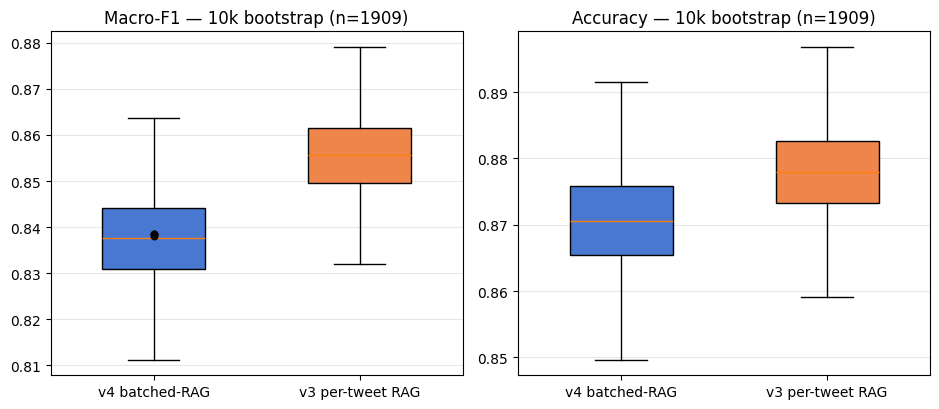

In [25]:
import matplotlib.pyplot as plt
os.makedirs("figures_v4", exist_ok=True)

def _boot(yp_arr, metric, n_boot=10000):
    rng = np.random.default_rng(RANDOM_STATE)
    out = np.empty(n_boot)
    for i in range(n_boot):
        s = rng.integers(0, len(yt), len(yt))
        out[i] = (f1_score(yt[s], yp_arr[s], average="macro") if metric == "f1_macro"
                  else accuracy_score(yt[s], yp_arr[s]))
    return out

names = ["v4 batched-RAG", "v3 per-tweet RAG"]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
for ax, metric, title in zip(axes, ["f1_macro", "accuracy"], ["Macro-F1", "Accuracy"]):
    data = [_boot(a, metric), _boot(b, metric)]
    bp = ax.boxplot(data, labels=names, showfliers=False, patch_artist=True, widths=0.5)
    for patch, c in zip(bp["boxes"], ["#4878d0", "#ee854a"]): patch.set_facecolor(c)
    if metric == "f1_macro":
        for r in seed_recs:
            ax.scatter(1, r["metrics"]["f1_macro"], color="black", zorder=5, s=22)
    ax.set_title(f"{title} — 10k bootstrap (n={len(yt)})"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("figures_v4/08_boxplots_v4_vs_v3.png", dpi=150); plt.show()

## 15. What to write in the report (v4 addendum)

- **Design.** Similarity-homogeneous mini-batches (KMeans over gte-small embeddings) + one shared,
  deduplicated retrieved-example block per batch + an explicit "uniform labels are expected" prompt.
- **Tuning.** Optuna TPE (30 trials, median pruning) on a stratified 400-tweet slice; 1,509-tweet
  untouched holdout confirms: holdout macro-F1 0.8447 vs tuning 0.8566 (mild slice overfit, honest gap).
- **Headline trade-off.** v3 keeps a small, real macro-F1 edge (paired ΔF1 ≈ −0.018, CI excludes 0);
  accuracies statistically tied (McNemar p ≈ 0.34). In exchange v4 uses ~8x fewer Azure calls
  (231 vs 1,909), runs ~6x faster, and cuts neutral leak by a third (158 → 104; 12.8% → 8.4%).
- **Stability.** Three grouping seeds: macro-F1 0.8384/0.8381/0.8385 — batch composition is a non-factor.
- **Optuna findings.** k=8 re-discovered; balanced per-class retrieval consistently hurt; shuffled
  example order beat similarity-sorted (known few-shot ordering effect).
- **Limitations.** Validation set reused across all versions' prompt iterations; Optuna saw only the
  tuning slice; temperature fixed at 0 for reproducibility.